In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
import scanpy as sc
import anndata as ad
import os

In [2]:
sc.settings.set_figure_params(dpi=50, facecolor="white")

In [3]:
work_dir = "/share/crsp/lab/dalawson/share/1_Lab_sequencing/1_Tatyana/Cellranger/nMFP_plus_Tumor_599_cellplex1/outs/per_sample_outs/"

In [4]:
adata_1 = sc.read_10x_h5(os.path.join(work_dir, 'nMFP_1/count/sample_filtered_feature_bc_matrix.h5'),
    gex_only=True
)
adata_1.obs["orig_ident"] = "nMFP_1"
adata_1.var_names_make_unique()
adata_1

/home/jovyan/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:1908: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 2496 × 32285
    obs: 'orig_ident'
    var: 'gene_ids', 'feature_types', 'genome'

In [5]:
adata_2 = sc.read_10x_h5(os.path.join(work_dir, 'nMFP_2/count/sample_filtered_feature_bc_matrix.h5'),
    gex_only=True
)
adata_2.obs["orig_ident"] = "nMFP_2"
adata_2.var_names_make_unique()
adata_2

/home/jovyan/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:1908: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 2220 × 32285
    obs: 'orig_ident'
    var: 'gene_ids', 'feature_types', 'genome'

In [6]:
adata_3 = sc.read_10x_h5(os.path.join(work_dir, 'nMFP_3/count/sample_filtered_feature_bc_matrix.h5'),
    gex_only=True
)
adata_3.obs["orig_ident"] = "nMFP_3"
adata_3.var_names_make_unique()
adata_3

/home/jovyan/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:1908: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 2048 × 32285
    obs: 'orig_ident'
    var: 'gene_ids', 'feature_types', 'genome'

In [7]:
adata_4 = sc.read_10x_h5(os.path.join(work_dir, 'nMFP_4/count/sample_filtered_feature_bc_matrix.h5'),
    gex_only=True
)
adata_4.obs["orig_ident"] = "nMFP_4"
adata_4.var_names_make_unique()
adata_4

/home/jovyan/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:1908: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 2089 × 32285
    obs: 'orig_ident'
    var: 'gene_ids', 'feature_types', 'genome'

In [8]:
adata_5 = sc.read_10x_h5(os.path.join(work_dir, 'nMFP_5/count/sample_filtered_feature_bc_matrix.h5'),
    gex_only=True
)
adata_5.obs["orig_ident"] = "nMFP_5"
adata_5.var_names_make_unique()
adata_5

/home/jovyan/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:1908: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 2254 × 32285
    obs: 'orig_ident'
    var: 'gene_ids', 'feature_types', 'genome'

In [9]:
adata_6 = sc.read_10x_h5(os.path.join(work_dir, 'tum599/count/sample_filtered_feature_bc_matrix.h5'),
    gex_only=True
)
adata_6.obs["orig_ident"] = "tum_599"
adata_6.var_names_make_unique()
adata_6

/home/jovyan/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:1908: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 9641 × 32285
    obs: 'orig_ident'
    var: 'gene_ids', 'feature_types', 'genome'

In [10]:
adatas = [adata_1, adata_2, adata_3, adata_4, adata_5, adata_6]
adata = ad.concat(adatas,  join="outer")
adata

AnnData object with n_obs × n_vars = 20748 × 32285
    obs: 'orig_ident'

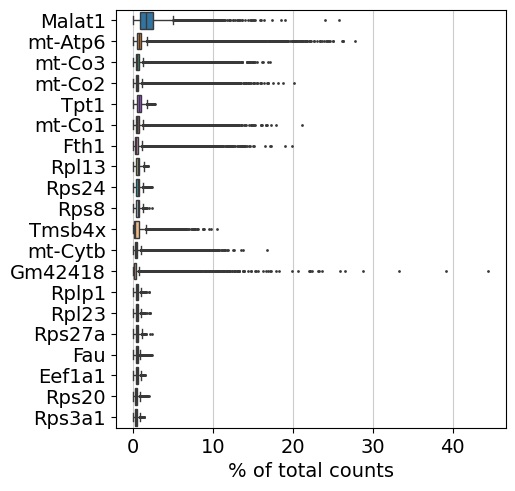

In [11]:
sc.pl.highest_expr_genes(adata, n_top=20)

In [12]:
sc.pp.filter_cells(adata, min_genes=500)
sc.pp.filter_genes(adata, min_cells=1)

In [13]:
adata.var["mt"] = adata.var_names.str.startswith("mt-")
adata.var["ribo"] = adata.var_names.str.startswith(("Rps", "Rpl"))
adata.var["hb"] = adata.var_names.str.startswith("Hbb")

sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True
)

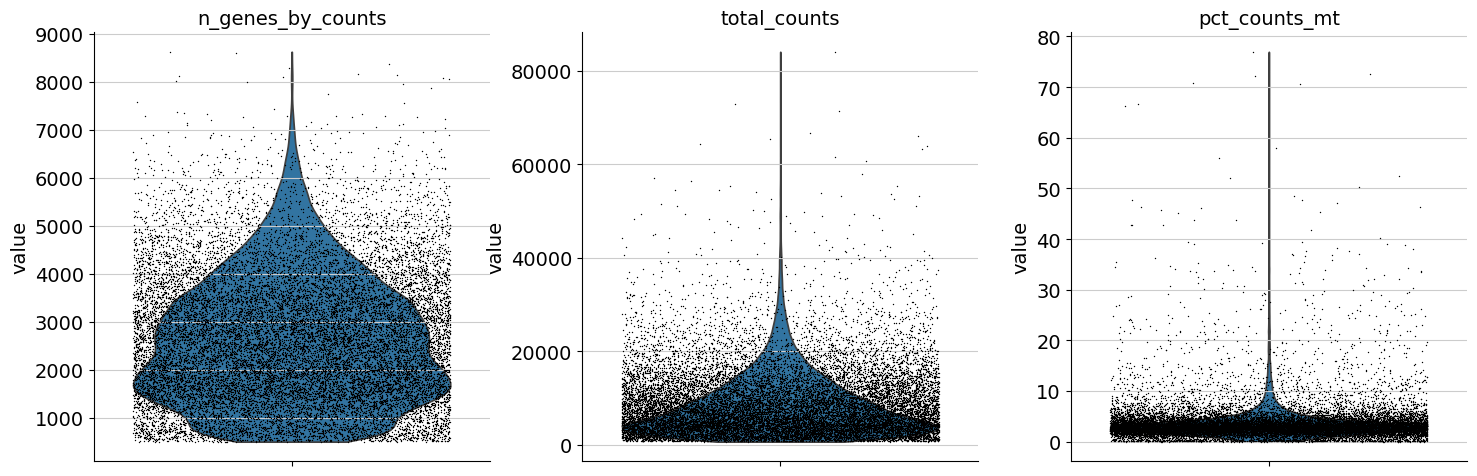

In [14]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

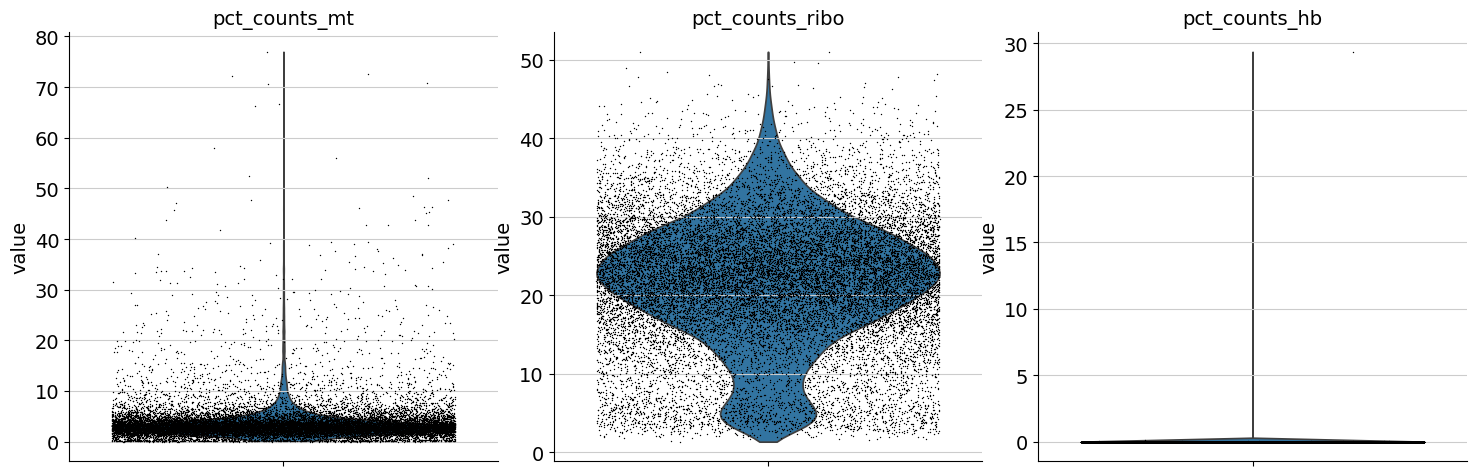

In [15]:
sc.pl.violin(
    adata,
    ["pct_counts_mt", "pct_counts_ribo", "pct_counts_hb"],
    jitter=0.4,
    multi_panel=True,
)

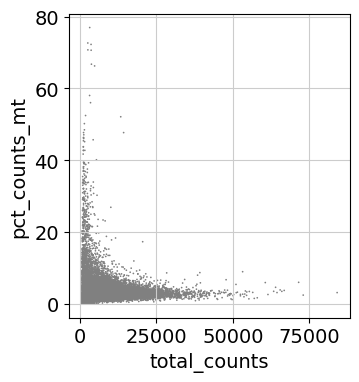

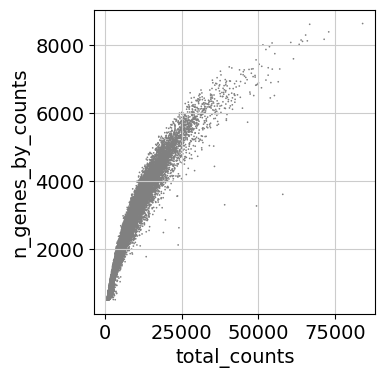

In [16]:
sc.pl.scatter(adata, x="total_counts", y="pct_counts_mt")
sc.pl.scatter(adata, x="total_counts", y="n_genes_by_counts")


In [17]:
adata = adata[adata.obs.n_genes_by_counts < 5000, :]
adata = adata[adata.obs.total_counts < 20000, :]
adata = adata[adata.obs.pct_counts_mt < 5, :]
adata = adata[adata.obs.pct_counts_ribo < 35, :]
adata = adata[adata.obs.pct_counts_hb < 2, :].copy()

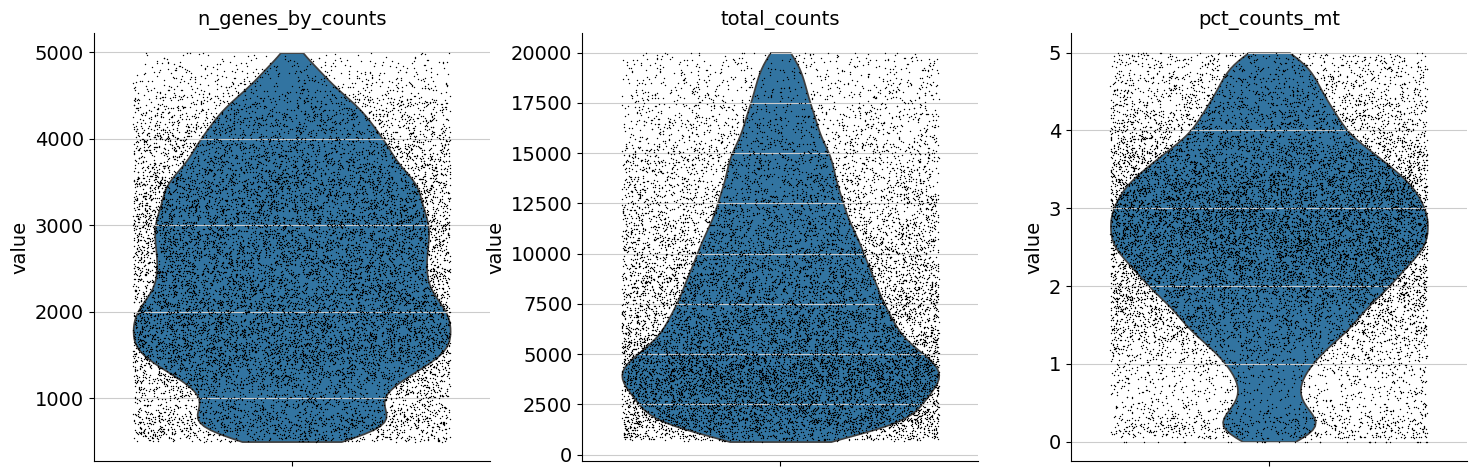

In [18]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

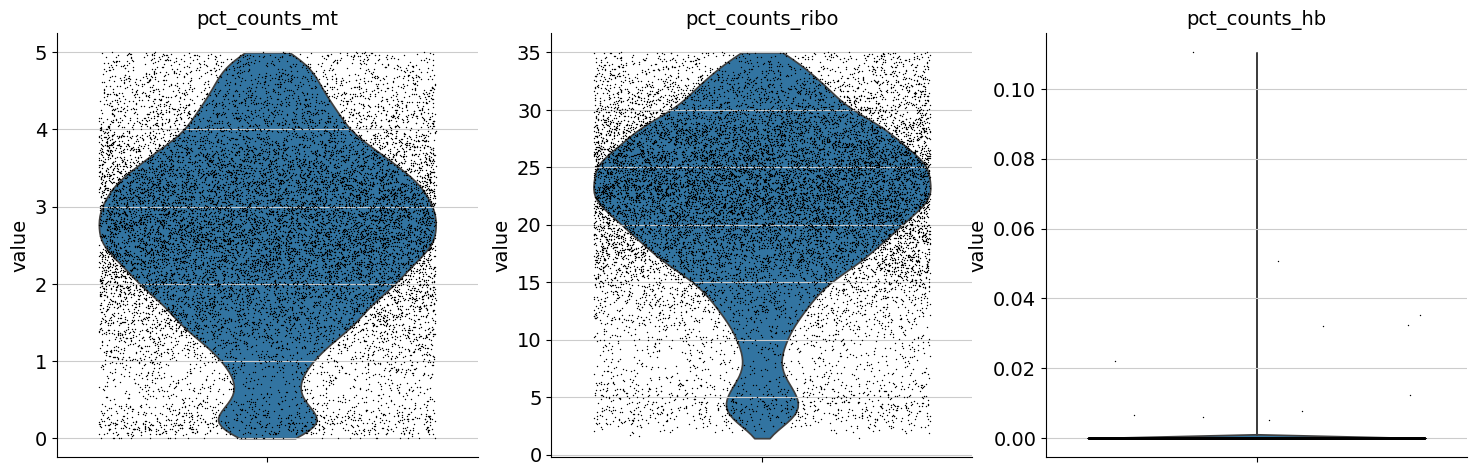

In [19]:
sc.pl.violin(
    adata,
    ["pct_counts_mt", "pct_counts_ribo", "pct_counts_hb"],
    jitter=0.4,
    multi_panel=True,
)

In [20]:
adata.layers["counts"] = adata.X.copy()

In [21]:
#save object and go to command line to run BigSur
adata.write('cellplex1.h5ad')

In [5]:
## start in bioportal ATAC, then go to SysBio24 

In [126]:
adata = sc.read_h5ad('cellplex1.h5ad')

In [127]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [128]:
adata.raw = adata

In [129]:
adata = adata[:, adata.var.highly_variable]
sc.pp.regress_out(adata, ['total_counts'])
sc.pp.scale(adata, max_value=10)

In [130]:
sc.tl.pca(adata, svd_solver="arpack")

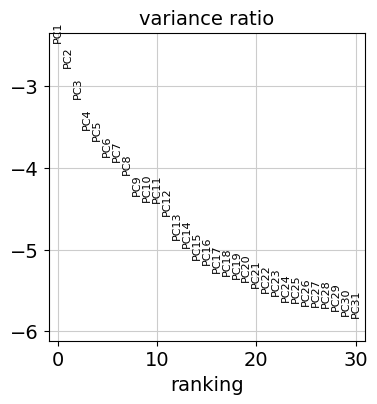

In [131]:
sc.pl.pca_variance_ratio(adata, log=True)

In [132]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)

In [133]:
sc.tl.leiden(
    adata,
    resolution=0.5,
    random_state=0,
    n_iterations=2,
    directed=False,
)

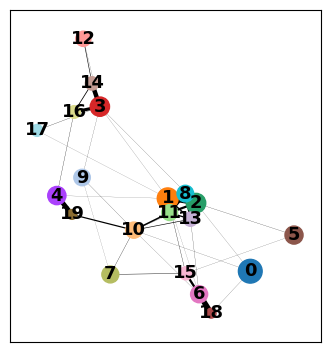

In [134]:
sc.tl.paga(adata)
sc.pl.paga(adata)
sc.tl.umap(adata, init_pos='paga')

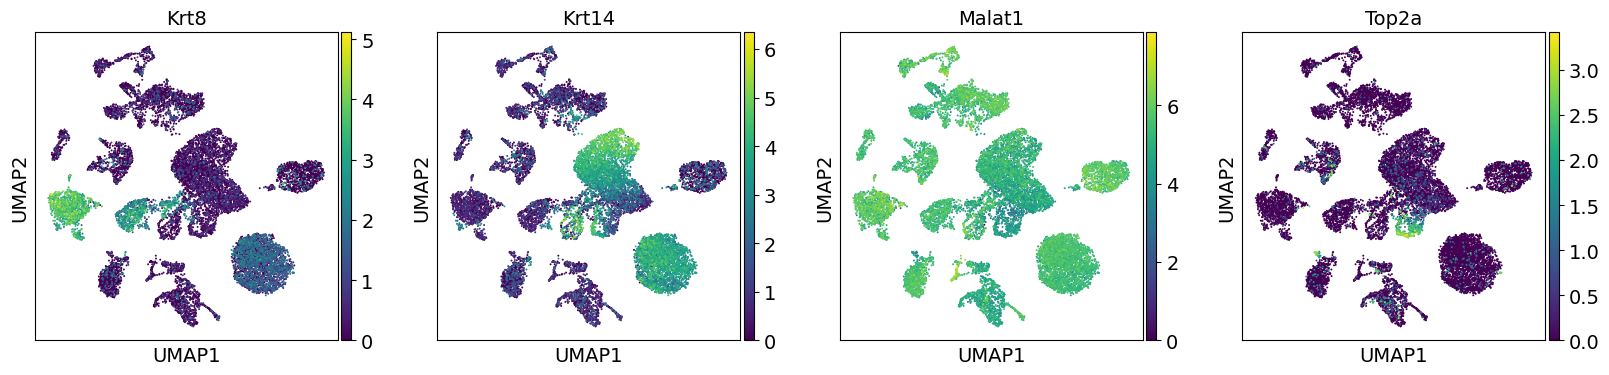

In [135]:
sc.pl.umap(adata, color=["Krt8", "Krt14", "Malat1", "Top2a"])

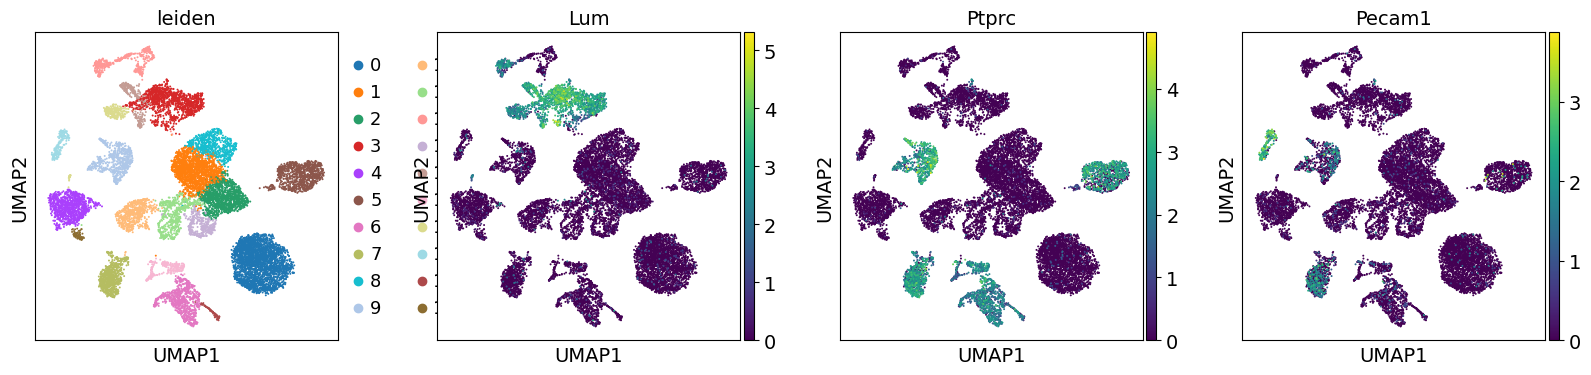

In [136]:
sc.pl.umap(adata, color=["leiden", "Lum", "Ptprc", "Pecam1"])

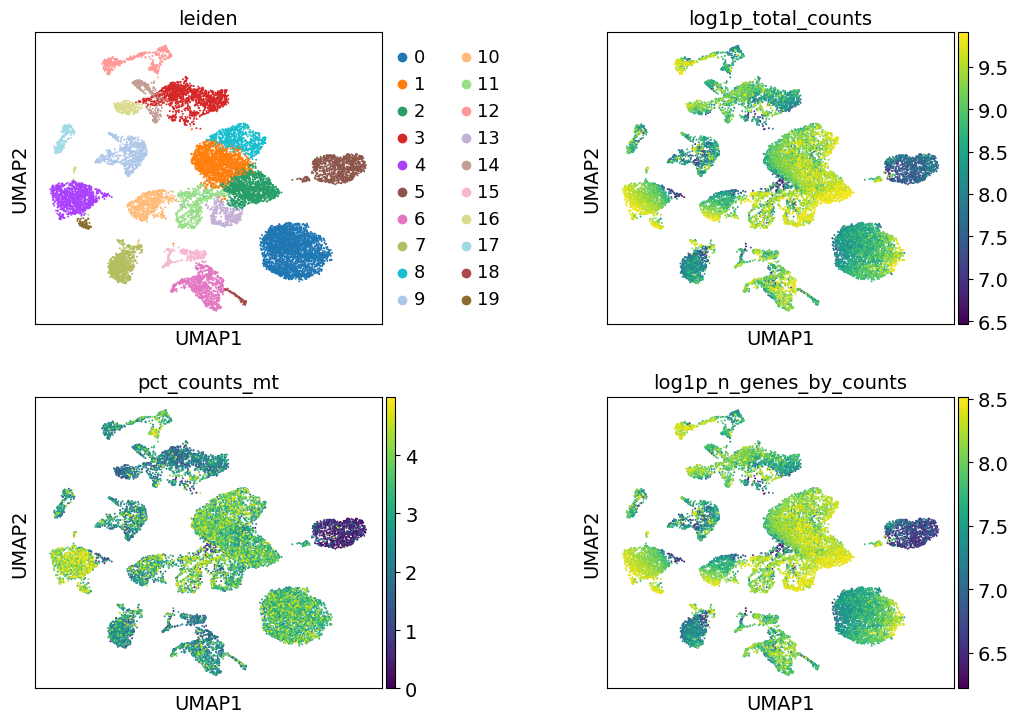

In [137]:
sc.pl.umap(
    adata,
    color=["leiden", "log1p_total_counts", "pct_counts_mt", "log1p_n_genes_by_counts"],
    wspace=0.5,
    ncols=2,
)

In [138]:
for res in [0.1, 0.2, 0.5]:
    sc.tl.leiden(
        adata, key_added=f"leiden_res_{res:4.2f}", resolution=res
    )

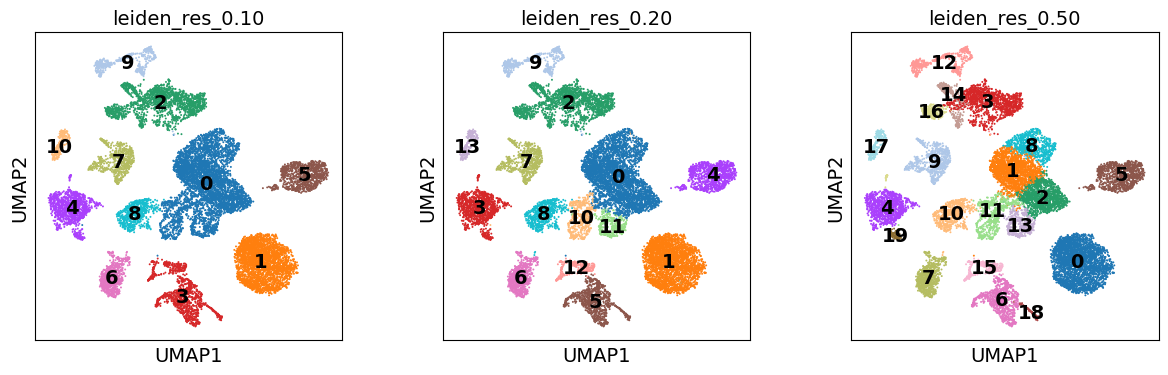

In [139]:
sc.pl.umap(
    adata,
    color=["leiden_res_0.10", "leiden_res_0.20", "leiden_res_0.50"],
    legend_loc="on data",
)

In [141]:
sc.tl.leiden(
    adata,
    resolution=0.10,
    random_state=0,
    n_iterations=2,
    directed=False,
)

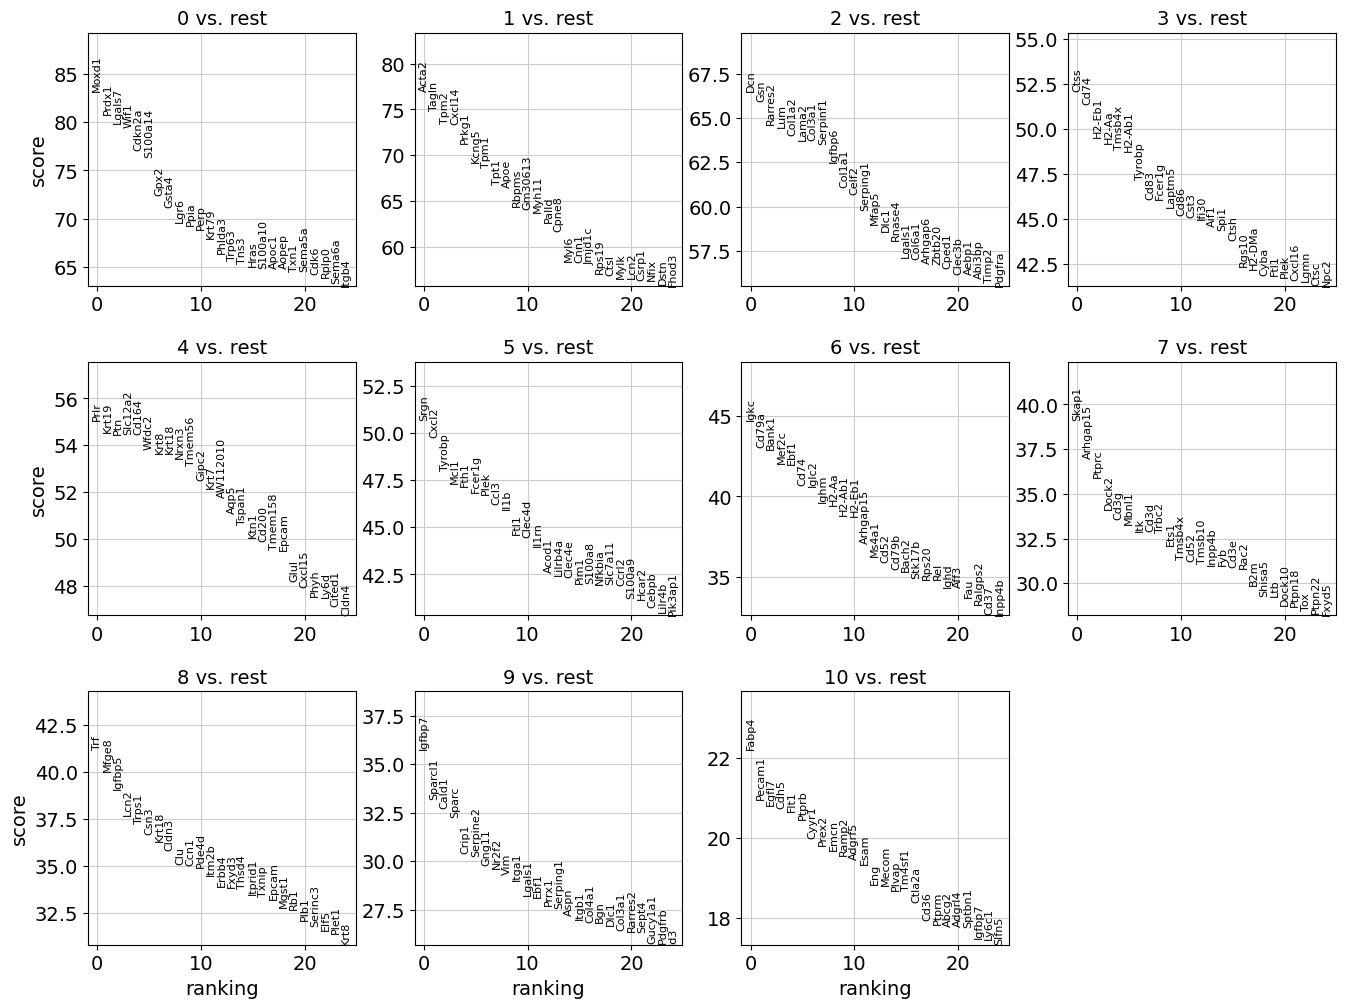

In [142]:
sc.tl.rank_genes_groups(adata, "leiden", method="wilcoxon")
sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False)

In [6]:
adata = sc.read_h5ad('/share/crsp/lab/dalawson/tzhuravl/CellPlex_Tumors/Scanpy_Seurat/cellplex_1/cellplex1.h5ad')

In [4]:
marker_genes = {
    "Proliferating": ["Top2a", "Mki67"],
    "Tumor": ["S100a14", "Cdkn2a"],
    "Basal": ["Krt5", "Krt14", "Trp63", "Tagln", "Acta2", "Mylk"],
    "Fibroblasts": ["Lum", "Dcn"],
    "Myeloid": ["Cd74"],
    "Tcells": ["Il7r"],
    "Bcells": ["Igkc"],
    "Neutrophils": ["Ptprc","Retnlg","Cxcr2","Ly6g","Mmp8"],
    "LumSec": ["Kit", "Krt8", "Krt18","Elf5"],
    "LumHR": ["Prlr", "Areg", "Esr1", "Pgr", "Erbb2", "Krt19"],
    "Pericytes": ["Rgs5"],
    "VSMC": ["Synm","Rergl","Pln"],
    "Perifibro": ["Sept4", "Col12a1", "Col8a1", "F2r"],
    "Adipo": ["Tenm2","Fat3","Apod","Idi1","Msmo1","Ifi30","Cyp51","Golph3"],
    "Schwann": ["Ecm1","Smoc2","Plp1","Mbp","Sox10","Ngfr"],
    "Endothelial": ["Pecam1"]
}

/home/jovyan/.local/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


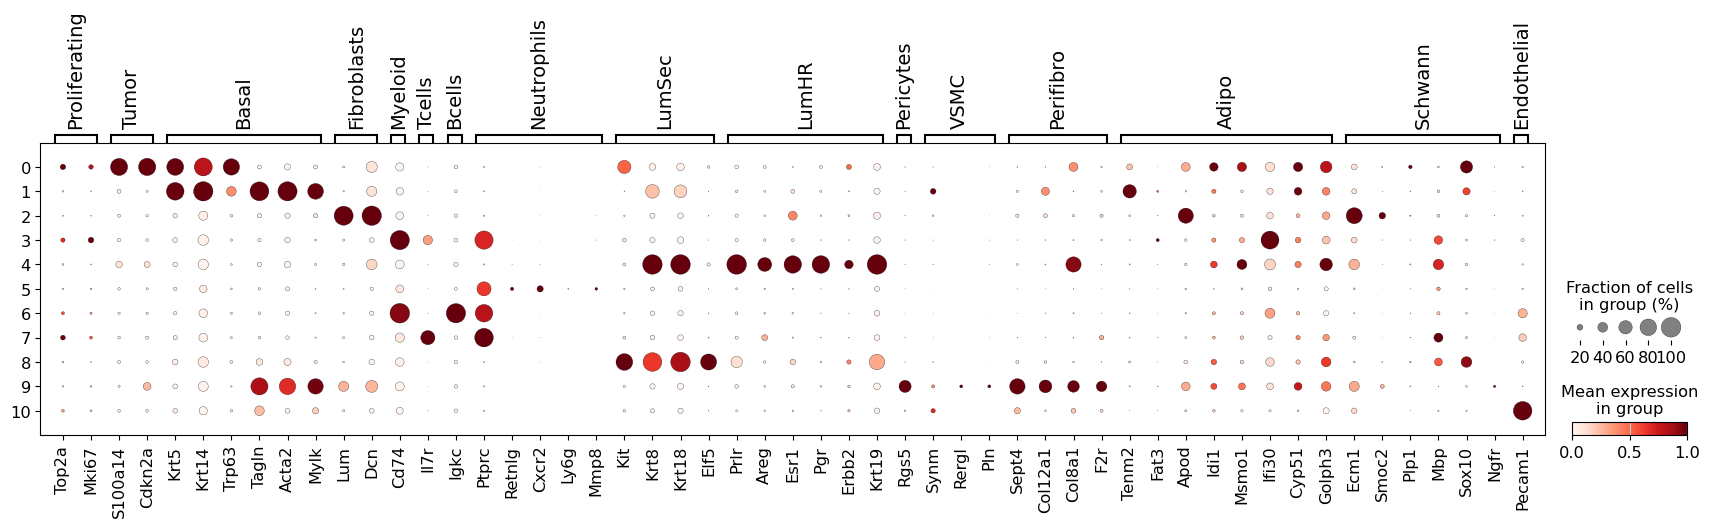

In [7]:
sc.pl.dotplot(adata, marker_genes, groupby="leiden_res_0.10", standard_scale="var")

In [147]:
adata.obs["cell_type"] = adata.obs["leiden_res_0.10"].map(
    {
        "0": "Tumor",
        "1": "Basal",
        "2": "Fibroblasts",
        "3": "Myeloid",
        "4": "LumHR",
        "5": "Neutrophils",
        "6": "Bcells",
        "7": "Tcells",
        "8": "LumSec",
        "9": "Pericytes",
        "10": "Endothelial"
    }
)

In [148]:
sc.tl.rank_genes_groups(adata, groupby="cell_type", method="wilcoxon")

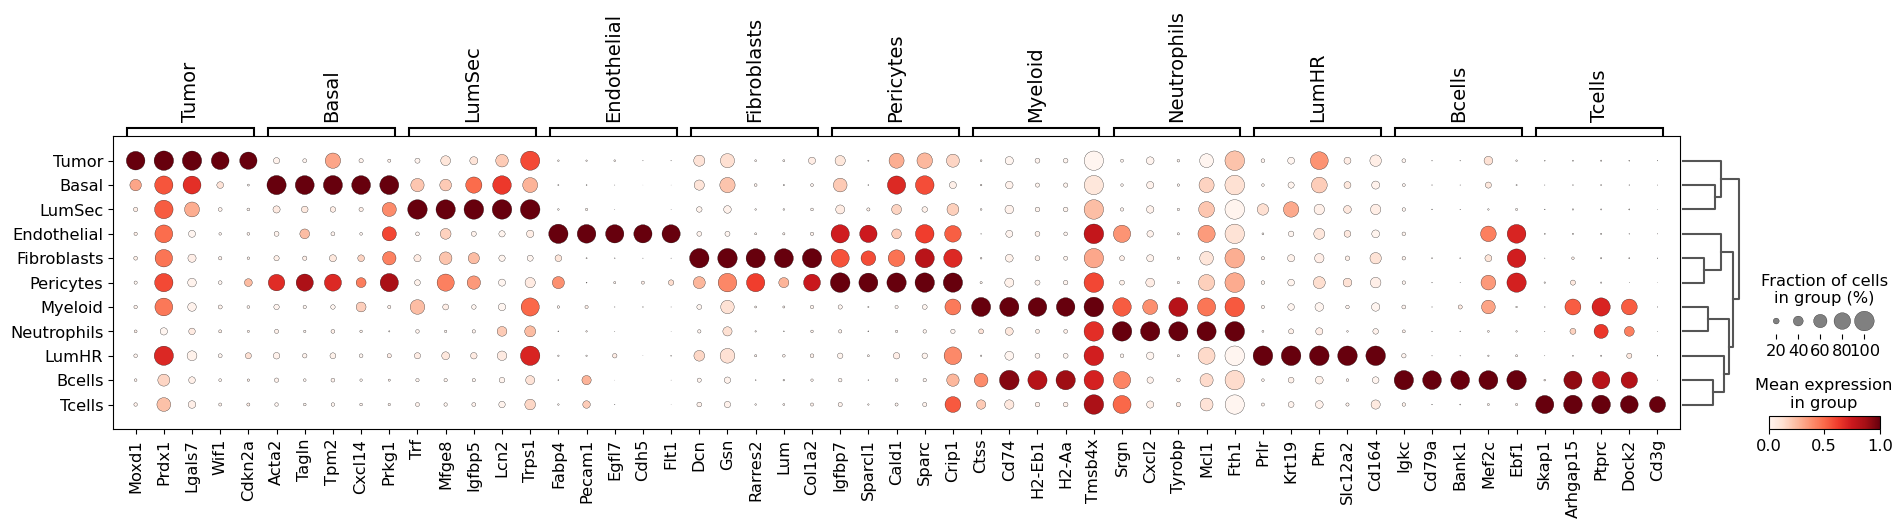

In [149]:
sc.pl.rank_genes_groups_dotplot(
    adata, groupby="cell_type", standard_scale="var", n_genes=5
)

In [150]:
adata.write('/share/crsp/lab/dalawson/tzhuravl/CellPlex_Tumors/Scanpy_Seurat/cellplex_1/cellplex1.h5ad')

In [9]:
from scipy import io
from scipy.sparse import coo_matrix, csr_matrix
import numpy as np
import os
import pandas as pd

In [153]:
adata.obs.to_csv('cellplex1.adata.obs.metadata.csv')

In [154]:
t=adata.raw.X.toarray()
pd.DataFrame(data=t, index=adata.obs_names, columns=adata.raw.var_names).to_csv('cellplex1.adata.raw.x.csv')

In [2]:
adata = sc.read_h5ad('/share/crsp/lab/dalawson/tzhuravl/CellPlex_Tumors/Scanpy_Seurat/cellplex_1/cellplex1.h5ad')

In [3]:
adata

AnnData object with n_obs × n_vars = 15047 × 1228
    obs: 'orig_ident', 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'leiden', 'leiden_res_0.10', 'leiden_res_0.20', 'leiden_res_0.50', 'cell_type'
    var: 'n_cells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'mc_Fano', 'FDR_adj_pvalue', 'p_value', 'highly_variable', 'mean', 'std'
    uns: 'CV_for_mc_Fano_fit', 'dendrogram_cell_type', 'leiden', 'leiden_colors', 'leiden_res_0.10_colors', 'leiden_res_0.20_colors', 'leiden_res_0.50_colors', 'leiden_sizes', 'log1p', 'neighbors', 'paga', 

In [8]:
hvg = sc.get.var_df(
    adata,
    keys=["highly_variable"]
)

hvg

,highly_variable
Xkr4,True
Sox17,True
Il17a,True
Il17f,True
Kcnq5,True
...,...
Radx,True
S100g,True
Tmsb4x,True
Frmpd4,True


In [10]:
hvg.to_csv('cellplex1.bigsur.hvg.csv')

In [12]:
clusters = sc.get.obs_df(
    adata,
    keys=["leiden_res_0.10"]
)

clusters

,leiden_res_0.10
AAACCCAGTACAGTTC-1,6
AAACGAATCAGTGTCA-1,7
AAACGAATCCTTATCA-1,6
AAACGCTTCCTGCTAC-1,7
AAAGAACTCTTACGGA-1,6
...,...
TTTGTTGCAAATGGAT-1,0
TTTGTTGCACAGCCTG-1,0
TTTGTTGCACTTCAAG-1,0
TTTGTTGCATCCGTTC-1,0


In [13]:
clusters.to_csv('cellplex1.bigsur.leiden.clusters.csv')

/home/jovyan/.local/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


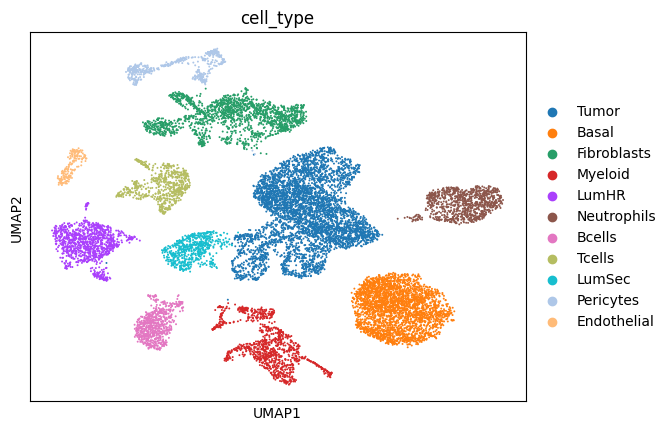

In [3]:
sc.pl.umap(
    adata,
    color=["cell_type"],
    wspace=0.5,
    ncols=2,
)